# Лабораторная работа 2: «Разработка сверточной нейронной сети с использованием PyTorch»
Выполнил: Ермолаев Илья группа 3823М1ФИии2

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torchsummary import summary
import time

In [2]:
# Проверка доступности GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
# Преобразования для данных
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

Загрузим тренировочный и тестовый наборы данных

In [4]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

Опрелим классы из CIFAR-10 дата сета.

In [5]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Проверим, что данные загружены корректно. Визуализируем несколько изображений с их метками

In [6]:
def show_images_with_labels(images, labels, class_names, nrows=2, ncols=4):
    plt.figure(figsize=(10, 5))
    for i in range(nrows * ncols):
        plt.subplot(nrows, ncols, i + 1)
        img = images[i] / 2 + 0.5
        npimg = img.numpy()
        plt.imshow(np.transpose(npimg, (1, 2, 0)))
        plt.title(class_names[labels[i]])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

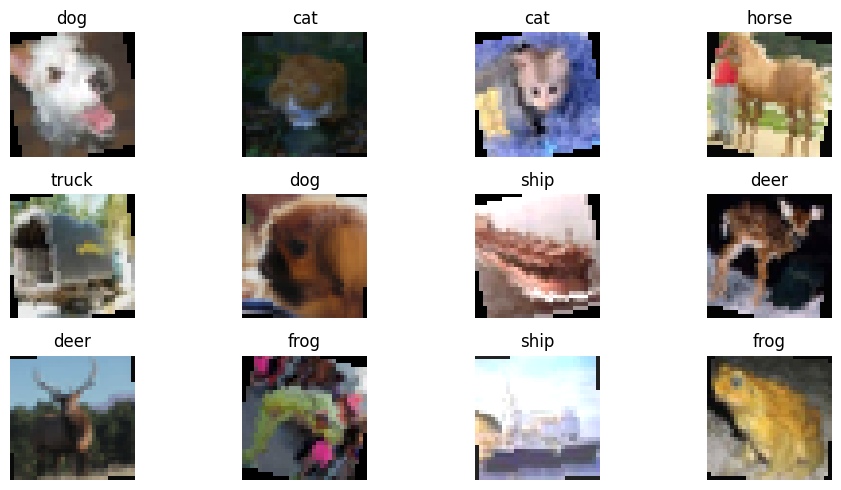

In [7]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Отображаем изображения с подписями классов
show_images_with_labels(images, labels, classes, nrows=3, ncols=4)

In [8]:
print('Number of train samples: {}'.format(len(trainset)))
print('Number of test samples: {}'.format(len(testset)))

Number of train samples: 50000
Number of test samples: 10000


Реализуем сверточную нейронную сеть.

In [9]:
class CNNet(nn.Module):
    def __init__(self):
        super(CNNet, self).__init__()

        # Сверточные слои
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
        )

        # Выравнивание
        self.flatten = nn.Flatten()

        # Полносвязные слои
        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 1024),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.6),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.6),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)  # Применяем сверточные слои
        x = self.flatten(x)  # Выравнивание для полносвязного слоя
        x = self.classifier(x)  # Применяем полносвязные слои
        return x

# Инициализация модели
model = CNNet().to(device)

In [10]:
model

CNNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.1)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): LeakyReLU(negative_slope=0.1)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): LeakyReLU(negative_slope=0.1)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation

In [11]:
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
       BatchNorm2d-2           [-1, 64, 32, 32]             128
         LeakyReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          36,928
       BatchNorm2d-5           [-1, 64, 32, 32]             128
         LeakyReLU-6           [-1, 64, 32, 32]               0
         MaxPool2d-7           [-1, 64, 16, 16]               0
            Conv2d-8          [-1, 128, 16, 16]          73,856
       BatchNorm2d-9          [-1, 128, 16, 16]             256
        LeakyReLU-10          [-1, 128, 16, 16]               0
           Conv2d-11          [-1, 128, 16, 16]         147,584
      BatchNorm2d-12          [-1, 128, 16, 16]             256
        LeakyReLU-13          [-1, 128, 16, 16]               0
        MaxPool2d-14            [-1, 12

Настроим гиперпараметры и обучим модель.

In [12]:
def format_time(elapsed_time):
  hours, remainder = divmod(elapsed_time, 3600)
  minutes, seconds = divmod(remainder, 60)
  return f"{int(hours):02}:{int(minutes):02}:{int(seconds):02}"

In [13]:
criterion = nn.CrossEntropyLoss()  # Функция потерь
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Оптимизатор

In [14]:
epochs = 40
train_losses, test_losses, test_accuracies  = [], [], []

In [15]:
start = time.time()
for epoch in range(epochs):
    start_epoch_time = time.time()
    running_loss = 0.0
    model.train()
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    end_epoch_time = time.time()

    # Вывод ошибки на тренировочном наборе
    train_loss = running_loss / len(trainloader)
    train_losses.append(train_loss)
    print(f'Epoch {epoch+1}, Train Loss: {train_loss:.3f}, Time: {format_time(end_epoch_time - start_epoch_time)}')

    # Оценка на тестовом наборе
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_loss = test_loss / len(testloader)
    test_losses.append(test_loss)
    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)
    print(f'Epoch {epoch+1}, Test Loss: {test_loss:.3f}, Accuracy: {accuracy:.2f}%')

end = time.time()
print('Total time {}'.format(format_time(end - start)))

Epoch 1, Train Loss: 1.680, Time: 00:00:57
Epoch 1, Test Loss: 1.364, Accuracy: 51.16%
Epoch 2, Train Loss: 1.239, Time: 00:00:53
Epoch 2, Test Loss: 1.019, Accuracy: 64.19%
Epoch 3, Train Loss: 1.008, Time: 00:00:52
Epoch 3, Test Loss: 0.933, Accuracy: 67.50%
Epoch 4, Train Loss: 0.866, Time: 00:00:52
Epoch 4, Test Loss: 0.765, Accuracy: 73.82%
Epoch 5, Train Loss: 0.778, Time: 00:00:53
Epoch 5, Test Loss: 0.771, Accuracy: 72.97%
Epoch 6, Train Loss: 0.719, Time: 00:00:54
Epoch 6, Test Loss: 0.651, Accuracy: 77.25%
Epoch 7, Train Loss: 0.667, Time: 00:00:53
Epoch 7, Test Loss: 0.617, Accuracy: 78.95%
Epoch 8, Train Loss: 0.627, Time: 00:00:52
Epoch 8, Test Loss: 0.597, Accuracy: 79.50%
Epoch 9, Train Loss: 0.598, Time: 00:00:53
Epoch 9, Test Loss: 0.650, Accuracy: 78.39%
Epoch 10, Train Loss: 0.568, Time: 00:00:53
Epoch 10, Test Loss: 0.594, Accuracy: 79.40%
Epoch 11, Train Loss: 0.545, Time: 00:00:53
Epoch 11, Test Loss: 0.552, Accuracy: 81.58%
Epoch 12, Train Loss: 0.525, Time: 00:0

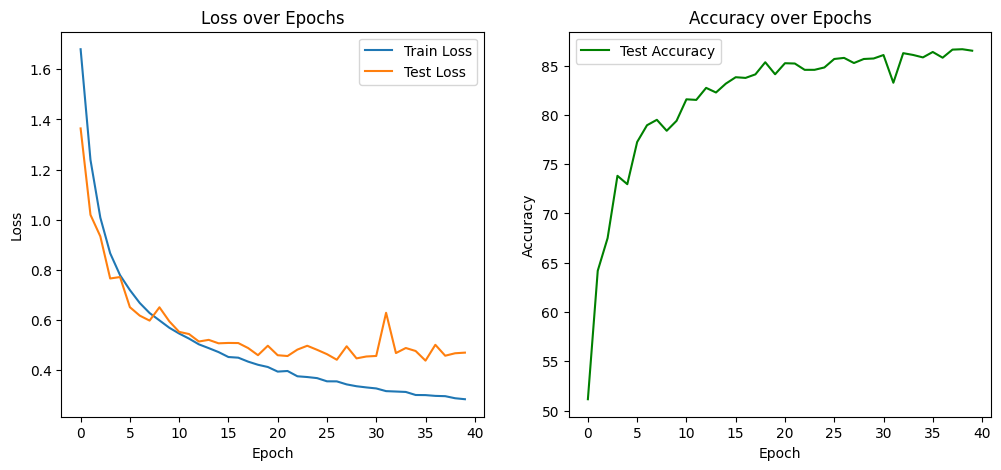

In [16]:
plt.figure(figsize=(12, 5))

# График Loss over Epochs
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# График Accuracy over Epochs
plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()

Тестируем модель

In [17]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        inputs, labels = data[0].to(device), data[1].to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy on test set: {100 * correct / total:.2f}%')

Accuracy on test set: 86.28%
